In [1]:
import numpy as np
import torch.nn as nn
import torch
from tqdm import tqdm
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Visualize Datasets

In [3]:
def make_gaussian(batch_size):
    # Sample from a 2D standard Gaussian (mean=0, std=1)
    return torch.randn(batch_size, 2)

def make_checkerboard(batch_size):
    # Sample the x-coordinate uniformly in the range [-2, 2)
    x1 = torch.rand(batch_size) * 4 - 2

    # Sample the y-coordinate:
    # Step 1: draw from uniform [0, 1)
    # Step 2: subtract either 0 or 2, randomly (via torch.randint)
    # Result: values centered roughly around -2 or -1
    x2_ = torch.rand(batch_size) - torch.randint(high=2, size=(batch_size, )) * 2

    # Add a vertical shift depending on whether the x1 bin is even or odd
    # This creates the alternating row offset of the checkerboard
    x2 = x2_ + (torch.floor(x1) % 2)

    # Stack x1 and x2 into (batch_size, 2) vectors, and scale the whole grid
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45

    return data.float()


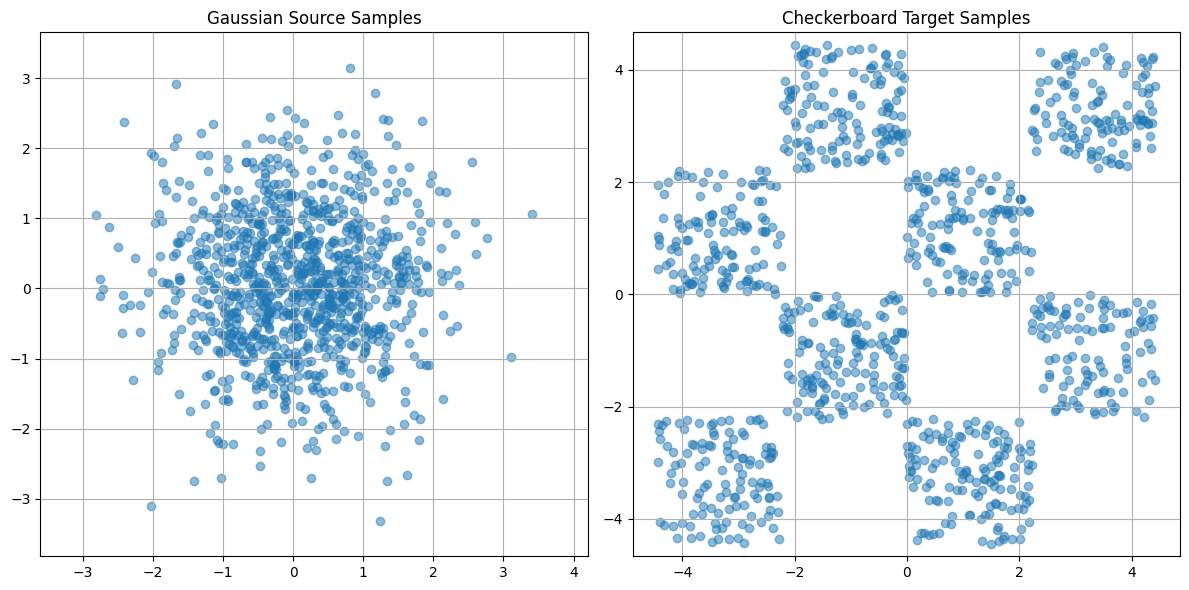

In [4]:
# Sample points
gaussian_samples = make_gaussian(1000)
checkerboard_samples = make_checkerboard(1000)

# Plot both
plt.figure(figsize=(12, 6))

# Plot Gaussian source
plt.subplot(1, 2, 1)
plt.scatter(gaussian_samples[:, 0], gaussian_samples[:, 1], alpha=0.5)
plt.title("Gaussian Source Samples")
plt.axis("equal")
plt.grid(True)

# Plot Checkerboard target
plt.subplot(1, 2, 2)
plt.scatter(checkerboard_samples[:, 0], checkerboard_samples[:, 1], alpha=0.5)
plt.title("Checkerboard Target Samples")
plt.axis("equal")
plt.grid(True)

plt.tight_layout()
plt.show()

# Neural Network

In [5]:
class FlowModel(nn.Module):  # Neural network to learn the time-dependent velocity field f(x, t)
  def __init__(self, input_dim=2, time_embed_dim=64):
    super().__init__()

    # Small MLP to embed the time scalar t into a higher-dimensional space
    self.time_embed = nn.Sequential(
        nn.Linear(1, time_embed_dim),
        nn.SiLU(),                     # Activation function: Sigmoid Linear Unit
        nn.Linear(time_embed_dim, time_embed_dim)
    )

    # Main network to predict velocity, given (x, embedded t)
    self.net = nn.Sequential(
        nn.Linear(input_dim + time_embed_dim, 128),  # Input: concatenated x and t embedding
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, input_dim)  # Output: predicted velocity (same dimension as x)
    )

  def forward(self, x, t):
    # Embed time t (shape: [batch_size, 1]) into a higher-dimensional vector
    t_embed = self.time_embed(t)

    # Concatenate position x and time embedding along the last dimension
    xt = torch.cat([x, t_embed], dim=-1)

    # Pass through the network to predict the velocity at (x, t)
    return self.net(xt)

# Flow Matching Loss

In [6]:
def flow_matching_loss(model, x0, x1, t):
  # Compute the interpolated point along the trajectory for each t
  xt = (1 - t) * x0 + t * x1

  # Compute the ground truth velocity vector (constant across trajectory)
  v_target = x1 - x0

  # Predict the velocity at point (x(t), t) using the model
  v_pred = model(xt, t)

  # Compute squared error between predicted and true velocity at each sample
  # Then average over the entire batch
  return ((v_pred - v_target) ** 2).mean()

# Sample Target + Source

In [7]:
def sample_target(batch_size):
    # Sample the x-coordinate uniformly in the range [-2, 2)
    x1 = torch.rand(batch_size) * 4 - 2

    # Sample the y-coordinate:
    # Step 1: draw from uniform [0, 1)
    # Step 2: subtract either 0 or 2, randomly (via torch.randint)
    # Result: values centered roughly around -2 or -1
    x2_ = torch.rand(batch_size) - torch.randint(high=2, size=(batch_size, )) * 2

    # Add a vertical shift depending on whether the x1 bin is even or odd
    # This creates the alternating row offset of the checkerboard
    x2 = x2_ + (torch.floor(x1) % 2)

    # Stack x1 and x2 into (batch_size, 2) vectors, and scale the whole grid
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45

    return torch.tensor(data, dtype=torch.float32)

In [8]:
def sample_source(batch_size):
    # Sample from a 2D standard Gaussian (mean=0, std=1)
    return torch.randn(batch_size, 2)

# Training Loop

In [9]:
num_steps = 10000
batch_size = 512
losses = []

model = FlowModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

for step in tqdm(range(num_steps)):
  x0 = sample_source(batch_size).to(device)
  x1 = sample_target(batch_size).to(device)
  t = torch.rand(batch_size, 1).to(device)  # Random interpolation time ∈ [0, 1]

  loss = flow_matching_loss(model, x0, x1, t)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if step % 100 == 0:
    print(f"Step {step} | Loss: {loss.item():.4f}")

  0%|          | 0/10000 [00:00<?, ?it/s]C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_8360\3261737578.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, dtype=torch.float32)
  0%|          | 9/10000 [00:00<01:59, 83.26it/s]

Step 0 | Loss: 7.8526


  1%|          | 107/10000 [00:01<01:48, 91.37it/s]

Step 100 | Loss: 4.0503


  2%|▏         | 214/10000 [00:02<01:50, 88.47it/s]

...

 98%|█████████▊| 9815/10000 [01:40<00:01, 137.71it/s]

Step 9800 | Loss: 4.0978


 99%|█████████▉| 9926/10000 [01:41<00:00, 148.46it/s]

Step 9900 | Loss: 3.8773


100%|██████████| 10000/10000 [01:41<00:00, 98.26it/s]


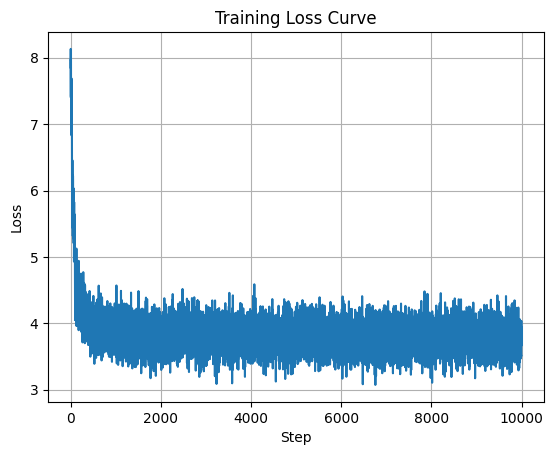

In [10]:
# Plot after training
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [11]:
def plot_velocity_row(model, t_values=[0.0, 0.25, 0.5, 0.75, 1.0], grid_size=20):
    model.eval()
    with torch.no_grad():
        # Set up grid and figure
        fig, axes = plt.subplots(1, len(t_values), figsize=(4 * len(t_values), 4))
        x = np.linspace(-4, 4, grid_size)
        y = np.linspace(-4, 4, grid_size)
        xx, yy = np.meshgrid(x, y)
        xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
        xt = torch.tensor(xy, dtype=torch.float32).to(device)

        for i, t_val in enumerate(t_values):
            # Repeat t for each grid point
            tt = torch.full((xt.shape[0], 1), t_val, dtype=torch.float32).to(device)

            # Predict velocity vectors
            v = model(xt, tt).cpu().numpy()

            # Plot velocity field as arrows
            ax = axes[i]
            ax.quiver(xx, yy,
                      v[:, 0].reshape(grid_size, grid_size),
                      v[:, 1].reshape(grid_size, grid_size),
                      scale=20)
            ax.set_title(f"t = {t_val}")
            ax.axis("equal")
            ax.grid(True)

        plt.tight_layout()
        plt.show()

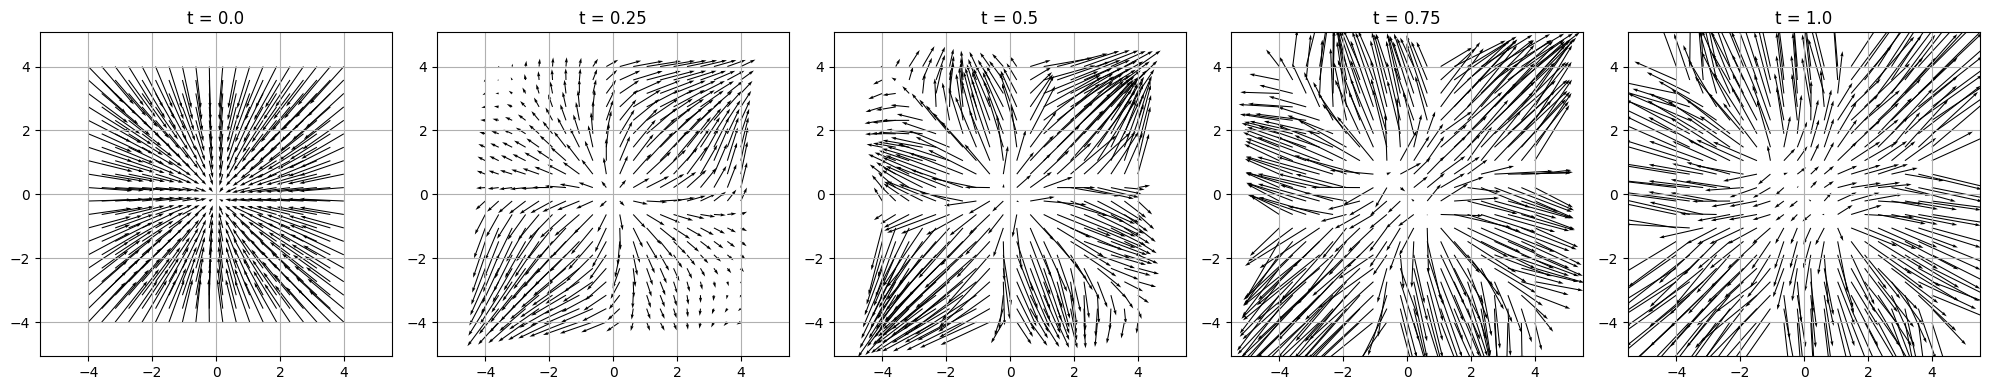

In [12]:
plot_velocity_row(model)

# Sampling (ODE Integration)

In [13]:
def sample_flow(model, x0, t_span=(0, 1)):
    """
    Evolve x0 through the learned flow to produce a sample from p1.
    """
    def ode_func(t, x):
        # Convert input x and time t into proper torch tensors
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        t_tensor = torch.tensor([[t]], dtype=torch.float32).to(device)

        # Predict velocity without tracking gradients
        with torch.no_grad():
            v = model(x_tensor, t_tensor)

        # Return velocity as NumPy array (shape: [2])
        return v.squeeze(0).cpu().numpy()

    # Solve ODE from t=0 to t=1 using the learned velocity field
    sol = solve_ivp(ode_func, t_span, x0.cpu().numpy(), t_eval=[t_span[1]])

    # Return the final state at t=1 (i.e. predicted x1)
    return sol.y[:, -1]

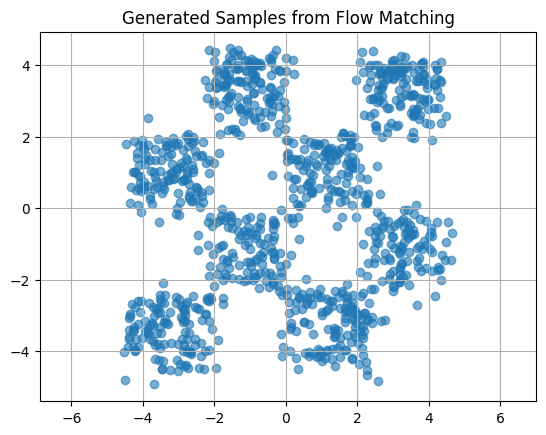

In [14]:
samples = []

# Sample 1000 points from the source distribution p₀
x0 = sample_source(1000).to(device)

# Push each point through the learned flow to generate a sample from p₁
for x in x0:
    with torch.no_grad():
        x = x.to(device)
        x1_hat = sample_flow(model, x, t_span=(0, 1))  # Integrate flow from t=0 to t=1
        samples.append(x1_hat)

# Convert list of sampled points to NumPy array for plotting
samples = np.array(samples)

# Scatter plot of generated samples in 2D
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.6)
plt.title("Generated Samples from Flow Matching")
plt.axis("equal")
plt.grid(True)
plt.show()

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_8360\3261737578.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, dtype=torch.float32)


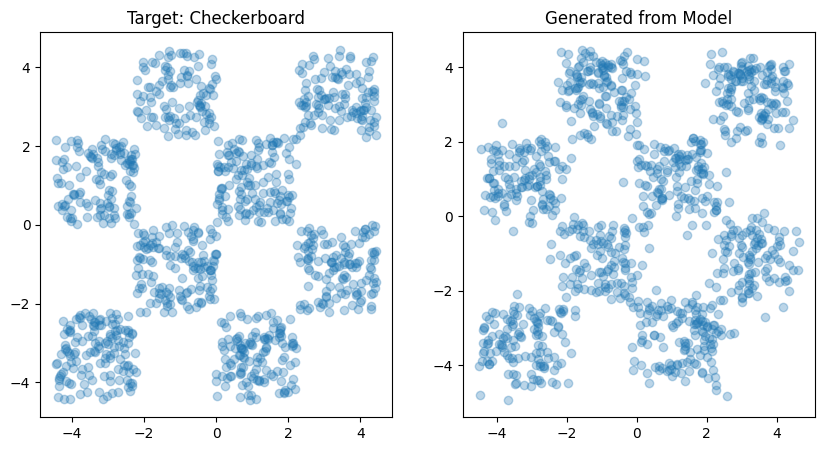

In [15]:
real = sample_target(1000)
gen = np.array(samples)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(real[:, 0], real[:, 1], alpha=0.3)
plt.title("Target: Checkerboard")

plt.subplot(1, 2, 2)
plt.scatter(gen[:, 0], gen[:, 1], alpha=0.3)
plt.title("Generated from Model")

plt.show()
